In [1]:
import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [2]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [3]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [4]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 1             # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.dist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones(sigTx_length, dtype=complex)

# 6) PA parameters 
PA_enable = True     # enable flag. If "False", the PA is skipped
PA_BO_dB = 3         # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB
BLPF_enable = True


# -----------------------------------------------
# Channel Parameters
#------------------------------------------------

# 1) Optical Channel Parameters
paramCh = parameters()
paramCh.Ltotal = 80       # total link distance [km]
paramCh.Lspan  = 80        # span length [km]
paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
paramCh.prgsBar = True     # show progress bar
paramCh.Fs = Rs*SpS        # sampling rate
paramCh.amp = 'edfa'       # type of amplifiers
paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
#paramCh.seed = 456


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = -128e6                # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 2

# 5) Chromatic Dispersion Parameters
paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

# 6) Adaptive Equalization Parameters
paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 2
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.constType = "qam"
paramEq.prgsBar = False

if M == 4:
   paramEq.alg = ['cma','cma'] # QPSK
   paramEq.mu = [5e-3, 1e-3]
else:
   paramEq.alg = ['da-rde','rde'] # M-QAM
   paramEq.mu = [5e-3, 5e-4] 

# 7) Carrier and Phase recovery parameters using bps
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType ="qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = True
paramCPR.Ts = 1/Rs

In [5]:
# ----------------------------------------------
# Simulation of the Optical System
# -----------------------------------------------

def simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD, paramRxPulse, paramDec, paramEDC, paramEq, paramCPR, P_launch_dBm, BLPF_enable):

    """
   This function simulates the optical transmission of a single-polarization, 
   single-channel 16/4-QAM signal.

    Parameters
    ----------
    Uses Global Parameters defined above

    Returns
    -------
    y_CPR_1 : 
        Received signal at end of DSP chain (after CPR)
    d:
        Noemlaized Symbol Synchronization with the SymbTx. Used in calculations.
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 1) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 2) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 3) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable = BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=3
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 4) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 5) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    sigCh = ssfm(sigTxo, paramCh)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    # Parameter which might change so needs to be in the function
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent Reciever for single-polarization.
    # Contains a 90 hybrid, two balanced photodiodes and iqmixing
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pusleshaping Function
    pulse = pulseShape(paramRxPulse) 
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation for non-linear channel
    sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD) 
    d = pnorm(symbRxCD)

    # 8) Adaptive Equalization Parameter which might change
    paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
    y_EQ = mimoAdaptEqualizer(x, paramEq, d)

    # 9) Carrier and Phase recovery using bps in the parameters
    y_CPR_1, θ = cpr(y_EQ, paramCPR)

    return y_CPR_1,d
    # End of RECEIVER
    # -----------------------------------------------------------------------------------------------------------------------------------------------------


In [9]:
def perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec):

    """Performance Metric Exploration for Single Polarization
    """

    # remove phase ambiguity for 4-QAM/QPSK
    if M == 16:
        discard = 5000
        ind = np.arange(discard, len(symbTx) - discard)

        d = symbTx

    # now compute metrics (both are 1 sample/symbol and same length)
        BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px = paramSymb.px)
        EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
        Qfactor = ber2Qfactor(BER[0])

        print(' SER: %.3e,  '%(SER[0]))
        print(' BER: %.3e   '%(BER[0]))
        print(' SNR: %.3f dB'%(SNR[0]))
        print(' EVM: %.3f %%'%(EVM[0]*100))
        print(' Qfactor: %.3f,  '%(Qfactor))

        
    return BER[0], EVM[0]*100

In [7]:
P_launch_dbm_list = [-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8]
ber_list = []
mzmScale = 0.8

symbTx = symbolSource(paramSymb)

for P_launch in tqdm(P_launch_dbm_list, desc="Launch Power Sweep", unit="power"):

    y_CPR_1, d = simulate_optical_system(
        symbTx, paramSymb, paramPulse, paramIQM, sigLO,
        paramCh, paramLO, paramFE, paramPD,
        paramRxPulse, paramDec, paramEDC, paramEq, paramCPR,
        P_launch, BLPF_enable
    )

    ber  = perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)
    ber_list.append(ber)

plt.figure()
plt.semilogy(P_launch_dbm_list, ber_list, 'o-')
plt.xlabel("Launch Power (dBm)")
plt.ylabel("BER")
plt.grid(True, which="both")
plt.title("BER vs Launch Power")
plt.show()



Launch Power Sweep:   0%|          | 0/12 [00:00<?, ?power/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.055704.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.049921.
rde - training stage #1
rde MSE = 0.030654.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 499.942 kHz


 SER: 2.833e-03,  
 BER: 7.111e-04   
 SNR: 17.655 dB
 EVM: 1.710 %
 Qfactor: 5.038,  


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.042741.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.036865.
rde - training stage #1
rde MSE = 0.024272.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 388.757 kHz


 SER: 8.556e-04,  
 BER: 2.167e-04   
 SNR: 19.337 dB
 EVM: 1.169 %
 Qfactor: 5.464,  


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

## BER vs Launch Power Graph

The **BER vs Launch Power** graph shows three distinct operating regions of the optical communication system.

---

### 1. Low Launch Power Region  
**Range:** approximately **-14 dBm to -4 dBm**

In this region, the **BER decreases clearly as launch power increases**.

This indicates that:

- The transmitted signal is **too weak at very low power levels**
- **ASE noise dominates**, limiting the effective signal quality
- Increasing launch power **improves the signal-to-noise ratio (SNR)**

As a result, the receiver can detect symbols more reliably and the **BER decreases**.

---

### 2. Optimum Operating Region  
**Range:** approximately **-2 dBm to +2 dBm**

In this region, the **BER reaches its minimum value**.

This indicates that:

- The transmitted power is **high enough to overcome noise**
- The power is **not yet high enough for nonlinear fiber effects to dominate**

From the graph, the optimum operating point appears to lie around **2 dBm**, with **-2 dBm, 0 dBm, and 2 dBm** showing very similar BER values.

This range therefore represents the **optimal launch power region** for the system.

---

### 3. High Launch Power Region  
**Range:** above approximately **+4 dBm**

In this region, the **BER begins to increase again**, especially beyond **6 dBm**.

This indicates that:

- **Nonlinear distortion becomes dominant**
- Effects such as **Self-Phase Modulation (SPM)** and other **nonlinear Kerr effects** distort the signal
- The system moves away from the optimal operating point

These nonlinear distortions degrade the constellation and increase the probability of symbol detection errors.

---

## U-Shaped BER Behaviour

Overall, the graph exhibits the expected **U-shaped BER vs Launch Power curve**:

- At **low launch powers**, the system is **noise-limited**, and BER decreases as launch power increases due to improved **SNR**.
- A **minimum BER** is observed in the **-2 dBm to +2 dBm region**, representing the **optimal operating point**.
- At **higher launch powers**, BER increases again as **nonlinear fiber impairments** become dominant.

---

## Validation of the Result

This graph provides a strong validation of the system behaviour because it demonstrates the **three expected operating regimes**:

1. **Low-power noise-limited region**
2. **Mid-power optimal operating region**
3. **High-power nonlinear-limited region**

This behaviour matches the expected physics of a **coherent optical transmission system**.

The graph also confirms that the simulation correctly captures the trade-off between:

- **ASE noise**, which dominates at **low launch powers**
- **Nonlinear Kerr effects**, which dominate at **high launch powers**

The optimal region around **-2 dBm to +2 dBm** is realistic for a **16-QAM coherent optical link** under these system conditions.

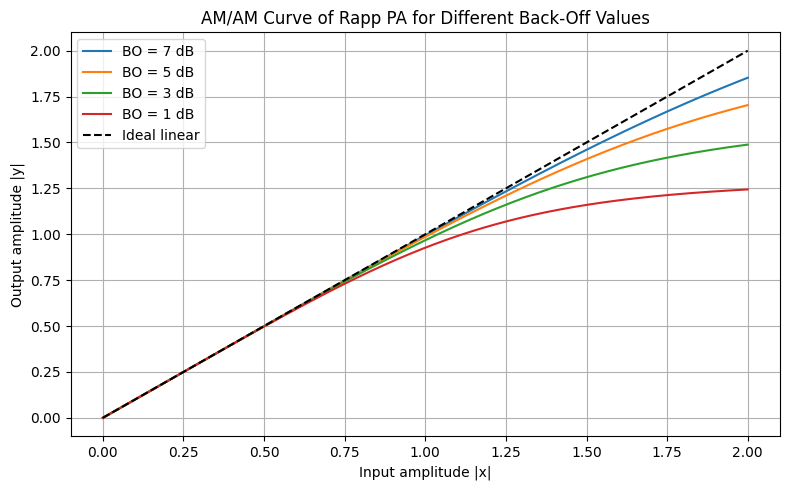

In [8]:
# ------------------------------------------------------------
# AM/AM curve of the PA for different back-off values
# ------------------------------------------------------------

# Input amplitude sweep
Ain = np.linspace(0, 2.0, 2000)

# Use a real-valued test input for AM/AM
x_test = Ain.astype(complex)

# Back-off values to compare
BO_list = [7, 5, 3, 1]

# Rapp parameter
p_rapp = 2.0

plt.figure(figsize=(8, 5))

for BO_dB in BO_list:
    # Define input RMS for this test sweep
    Vrms = np.sqrt(np.mean(np.abs(x_test) ** 2))

    # Same BO definition as in your pa_model()
    Vsat = Vrms * 10 ** (BO_dB / 20)

    # Pass through Rapp PA
    y_test = rapp_pa(x_test, Vsat=Vsat, p=p_rapp)

    # Output amplitude
    Aout = np.abs(y_test)

    plt.plot(Ain, Aout, label=f'BO = {BO_dB} dB')

# Ideal linear line
plt.plot(Ain, Ain, 'k--', label='Ideal linear')

plt.xlabel('Input amplitude |x|')
plt.ylabel('Output amplitude |y|')
plt.title('AM/AM Curve of Rapp PA for Different Back-Off Values')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## AM/AM Curve of Rapp PA for Different Back-Off Values

The graph shows the relationship between the **input amplitude** $|x|$ and the **output amplitude** $|y|$ of the Power Amplifier (PA) for different **back-off (BO)** values.  
The **dashed black line** represents an *ideal linear amplifier*, where the output amplitude increases proportionally with the input amplitude.

---

### 1. Linear Region at Low Amplitudes

For input amplitudes approximately between **0 and 0.8–1**, all curves closely follow the ideal linear response.

This indicates that:

- The amplifier operates in its **linear region**
- The **gain is approximately constant**
- The signal experiences **negligible distortion**

This is the expected behavior because the amplifier is operating **far from its saturation limit**.

---

### 2. Onset of Gain Compression

As the input amplitude increases beyond approximately **$|x| \approx 1$**, the curves begin to deviate from the ideal linear line.

This deviation indicates the onset of **gain compression**, where:

- The output amplitude grows **more slowly** than the input amplitude
- The amplifier **gain decreases** with increasing input power
- The device begins to **approach saturation**

This behavior is typical of **nonlinear power amplifiers**.

---

### 3. Saturation Region

At higher input amplitudes, the curves flatten further.

This means:

- Increasing the input amplitude produces **only small increases in output amplitude**
- The amplifier is **approaching saturation**
- **Strong amplitude distortion** occurs

This is the region where **nonlinear effects become dominant**.

---

## Effect of Back-Off (BO)

Back-off controls how far the amplifier operates from its saturation point.

### BO = 7 dB (Blue Curve)

This curve remains closest to the ideal linear response.

**Implications:**

- The amplifier operates **well within the linear region**
- **Nonlinear distortion is minimal**
- **Signal quality is preserved**

This represents **weak PA nonlinearity**.

---

### BO = 5 dB (Orange Curve)

This curve begins to compress slightly earlier.

**Implications:**

- **Moderate nonlinearity** appears
- Some **amplitude compression** occurs for larger signals

---

### BO = 3 dB (Green Curve)

Compression becomes more noticeable.

**Implications:**

- The amplifier approaches **saturation sooner**
- Larger amplitude signals are **significantly compressed**

---

### BO = 1 dB (Red Curve)

This curve exhibits the **strongest compression**.

**Implications:**

- The amplifier operates **very close to saturation**
- **Strong nonlinear distortion** occurs
- Large amplitude inputs are **heavily compressed**

This represents **strong PA nonlinearity**.

---

## Implications for the 16-QAM System

This behavior has important consequences for the transmitted signal.

In **16-QAM**, constellation points have **different amplitudes**:

- **Inner points** → lower amplitude  
- **Outer points** → higher amplitude  

Because the PA compresses **larger amplitudes more strongly**:

- Outer constellation points are **compressed toward the center**
- The **distance between amplitude levels decreases**
- **EVM increases**
- **BER worsens**

Therefore:

- **Larger BO values → better signal quality**
- **Smaller BO values → stronger distortion and worse system performance**

---

## Validation of the PA Model

The plot validates that the **Rapp PA model** is behaving correctly because it shows the expected characteristics:

- Linear behavior at **low amplitudes**
- **Smooth transition** into gain compression
- **Saturation** at high amplitudes
- **Stronger compression for smaller BO values**

These are the typical features of a **realistic nonlinear power amplifier model**.

---

## Summary

The AM/AM characteristic of the Rapp power amplifier demonstrates how **back-off controls the degree of nonlinearity** in the transmitter.  
At low input amplitudes the amplifier behaves linearly, but as the input amplitude increases, **gain compression and saturation occur**. Lower back-off values lead to **earlier and stronger compression**, increasing nonlinear distortion.

This distortion particularly affects **amplitude-sensitive constellations such as 16-QAM**, leading to degraded **EVM and BER performance** in the communication system.

Back-off (BO) Sweep:   0%|          | 0/7 [00:00<?, ?BO factor/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.064402.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.058553.
rde - training stage #1
rde MSE = 0.032763.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 458.585 kHz


 SER: 4.800e-03,  
 BER: 1.217e-03   
 SNR: 17.509 dB
 EVM: 1.787 %
 Qfactor: 4.817,  


  0%|          | 0/1 [00:00<?, ?it/s]

...

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.027833.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.021970.
rde - training stage #1
rde MSE = 0.016888.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 347.891 kHz


 SER: 4.444e-05,  
 BER: 1.111e-05   
 SNR: 20.958 dB
 EVM: 0.802 %
 Qfactor: 6.275,  


  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.025799.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.019927.
rde - training stage #1
rde MSE = 0.015661.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 348.505 kHz


 SER: 2.222e-05,  
 BER: 5.556e-06   
 SNR: 21.224 dB
 EVM: 0.753 %
 Qfactor: 6.429,  


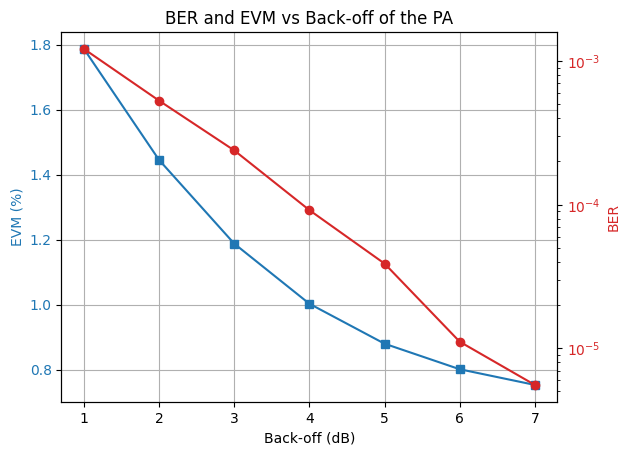

In [ ]:
BO_list = [1, 2, 3, 4, 5, 6, 7]
P_launch_dbm_BO = 0
ber_list_BO = []
evm_list_BO = []

symbTx = symbolSource(paramSymb)

for BO_value in tqdm(BO_list, desc="Back-off (BO) Sweep", unit="BO factor"):

    PA_BO_dB = BO_value # manually over-ride global variable

    y_CPR_1, d = simulate_optical_system(
        symbTx, paramSymb, paramPulse, paramIQM, sigLO,
        paramCh, paramLO, paramFE, paramPD,
        paramRxPulse, paramDec, paramEDC, paramEq, paramCPR,
        P_launch_dbm_BO, BLPF_enable
    )

    ber, evm  = perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)
    ber_list_BO.append(ber)
    evm_list_BO.append(evm)

# plt.figure()
# plt.semilogy(BO_list, ber_list_BO, 'o-')
# plt.xlabel("Back-off (dB)")
# plt.ylabel("BER")
# plt.grid(True, which="both")
# plt.title("BER vs Back-off of the PA")
# plt.show()

# fig, ax1 = plt.subplots()

# # Left axis → EVM (linear scale)
# ax1.plot(BO_list, evm_list_BO, 's-', color='tab:blue', label="EVM")
# ax1.set_xlabel("Back-off (dB)")
# ax1.set_ylabel("EVM (%)", color='tab:blue')
# ax1.tick_params(axis='y', labelcolor='tab:blue')
# ax1.grid(True)

# # Right axis → BER (log scale)
# ax2 = ax1.twinx()
# ax2.semilogy(BO_list, ber_list_BO, 'o-', color='tab:red', label="BER")
# ax2.set_ylabel("BER", color='tab:red')
# ax2.tick_params(axis='y', labelcolor='tab:red')

# plt.title("BER and EVM vs Back-off of the PA")

# plt.show()




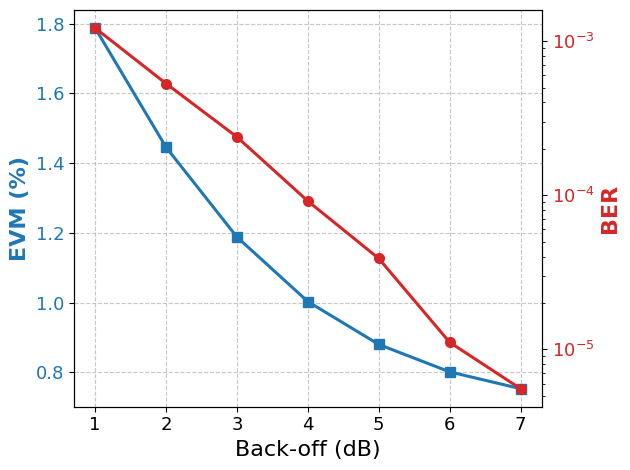

In [13]:
#fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
fig, ax1 = plt.subplots()

# Left axis -> EVM
ax1.plot(BO_list, evm_list_BO, 's-', linewidth=2.2, markersize=7, color='tab:blue')
ax1.set_xlabel("Back-off (dB)", fontsize=16)
ax1.set_ylabel("EVM (%)", fontsize=16, fontweight='bold', color='tab:blue')
ax1.tick_params(axis='x', labelsize=13)
ax1.tick_params(axis='y', labelsize=13, labelcolor='tab:blue')
ax1.grid(True, which="both", linestyle='--', alpha=0.7)

# Right axis -> BER
ax2 = ax1.twinx()
ax2.semilogy(BO_list, ber_list_BO, 'o-', linewidth=2.2, markersize=7, color='tab:red')
ax2.set_ylabel("BER", fontsize=16, fontweight='bold', color='tab:red')
ax2.tick_params(axis='y', labelsize=13, labelcolor='tab:red')

#plt.title("BER and EVM vs Back-off of the PA", fontsize=17, fontweight='bold')

plt.tight_layout()
plt.savefig("BER_EVM_vs_BO.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis of the BER vs Back-Off of the PA Plot

The plot shows the variation of the **Bit Error Rate (BER)** with the **power amplifier back-off (BO)** for a fixed optical launch power of **0 dBm**.

The overall trend is a **monotonic decrease in BER as BO increases**, which is physically consistent with the expected behavior of a nonlinear power amplifier.

---

### 1. Low Back-Off Region (1–2 dB)

In this region, the BER is highest, with values on the order of:

- around \(10^{-3}\) at **1 dB**
- a few \(10^{-4}\) at **2 dB**

This indicates that the PA is operating **very close to saturation**.

At low BO:

- the amplifier experiences **strong gain compression**
- large-amplitude signal samples are distorted more heavily
- symbol decision errors increase significantly

Since **16-QAM is amplitude-sensitive**, this nonlinear compression has a strong impact on BER.

---

### 2. Intermediate Back-Off Region (3–5 dB)

At **3–5 dB**, the BER continues to decrease rapidly, moving from around \(10^{-4}\) toward \(10^{-5}\).

This shows that:

- increasing BO moves the PA **further away from saturation**
- nonlinear distortion is **reduced**
- the transmitted waveform becomes **more linear**
- the receiver DSP can recover the signal **more effectively**

This region is important because it shows that **PA nonlinearity is the dominant impairment** in the lower BO operating range.

---

### 3. High Back-Off Region (6–7 dB)

At higher BO values, the BER becomes very small, reaching values close to the lower end of the simulated range.

This indicates that:

- the PA is now operating in a **more linear region**
- amplitude distortion is **minimal**
- the remaining BER is likely limited by other impairments, such as:

    - channel noise  
    - residual phase error  
    - equalization limitations  
    - finite simulation resolution  

At **7 dB**, the BER may become extremely small or even zero in the simulation, which does not display properly on a **logarithmic axis**.

---

## Physical Interpretation

Back-off determines how far the PA operates from its saturation point.

- **Small BO** means the amplifier is driven hard, close to saturation.
- **Large BO** means the amplifier operates more linearly.

Therefore:

- **low BO → strong nonlinear distortion → high BER**
- **high BO → weak nonlinear distortion → low BER**

This is exactly the trend observed in the plot.

For a **16-QAM signal**, this result is particularly meaningful because the constellation has **multiple amplitude levels**. The PA affects the **outer constellation points more strongly** than the inner points, so amplitude compression directly reduces symbol spacing and increases the probability of symbol detection errors.

---

## Validation of the Plot

This plot provides a good validation of the system because it demonstrates the expected impact of **transmitter nonlinearity on communication performance**.

The result is valid because it shows:

- **High BER at low BO**, where PA saturation is strong  
- **Progressive BER improvement as BO increases**, due to improved PA linearity  
- A trend that matches the **AM/AM curve of the Rapp PA model**

This confirms that:

- the PA model affects the transmitted signal as expected
- the system is sensitive to PA compression
- receiver performance improves as the PA becomes more linear

The plot therefore validates that the simulation correctly captures the effect of **PA back-off on BER**.